In [26]:
import glob
import pandas as pd
import ezc3d
import matplotlib.pyplot as plt

# Paths
DB = "DB5"
PX = "P32"

c3d_dir = f"../data/{DB}_retargeted/{PX}"
#c3d_filt_dir = "../data/DB1_filtered/P01"
trc_dir = f"../results/{DB}/{PX}/IK/MarkerData"
mot_dir = f"../results/{DB}/{PX}/ID/GRF"

# 1. Inspect file structures (Pick the first file as a sample)
c3d_file = glob.glob(f"{c3d_dir}/*.c3d")[0]
#c3dfilt_file = glob.glob(f"{c3d_filt_dir}/*.c3d")[0]
trc_file = glob.glob(f"{trc_dir}/*.trc")[4]
mot_file = glob.glob(f"{mot_dir}/*.mot")[1]

# Inspect C3D
c = ezc3d.c3d(c3d_file)
#cfilt = ezc3d.c3d(c3dfilt_file)
print("--- C3D Contents ---")
print("Points:", c['parameters']['POINT']['LABELS']['value'])
print("Analogs:", c['parameters']['ANALOG']['LABELS']['value'])

# Inspect TRC
trc_df = pd.read_csv(trc_file, sep='\t', header=[3])
trc_coord = pd.read_csv(trc_file, sep='\t', header=[4])
print("\n--- TRC Columns ---")
print(trc_df.columns.tolist())
print(trc_coord.columns.tolist())

# Inspect MOT
# MOT files usually have a header ending with 'endheader'
with open(mot_file, 'r') as f:
    lines = f.readlines()
    header_idx = [i for i, line in enumerate(lines) if 'endheader' in line][0]
mot_df = pd.read_csv(mot_file, sep='\t', skiprows=header_idx + 1)
print("\n--- MOT Columns ---")
print(mot_df.columns.tolist())


--- C3D Contents ---
Points: ['LASI', 'RASI', 'RPSI', 'LPSI', 'CLAV', 'RSHO', 'LSHO', 'C7', 'RKNE', 'LKNE', 'RANK', 'LANK', 'RHEE', 'LHEE', 'RTOE', 'LTOE', 'RMT5', 'LMT5', 'RTHI', 'LTHI', 'RTIB', 'LTIB']
Analogs: ['Force.Fx1', 'Force.Fy1', 'Force.Fz1', 'Moment.Mx1', 'Moment.My1', 'Moment.Mz1', 'Force.Fx2', 'Force.Fy2', 'Force.Fz2', 'Moment.Mx2', 'Moment.My2', 'Moment.Mz2', 'Force.Fx3', 'Force.Fy3', 'Force.Fz3', 'Moment.Mx3', 'Moment.My3', 'Moment.Mz3', 'Force.Fx4', 'Force.Fy4', 'Force.Fz4', 'Moment.Mx4', 'Moment.My4', 'Moment.Mz4', 'Force.Fx5', 'Force.Fy5', 'Force.Fz5', 'Moment.Mx5', 'Moment.My5', 'Moment.Mz5', 'Electric Potential.A', 'Electric Potential.B', 'Electric Potential.StartStop', 'Voltage.Right', 'Voltage.Left', 'Electric Potential.EEGSync']

--- TRC Columns ---
['Frame#', 'Time', 'C7', 'Unnamed: 3', 'Unnamed: 4', 'CLAV', 'Unnamed: 6', 'Unnamed: 7', 'LANK', 'Unnamed: 9', 'Unnamed: 10', 'LASI', 'Unnamed: 12', 'Unnamed: 13', 'LHEE', 'Unnamed: 15', 'Unnamed: 16', 'LKNE', 'Unname

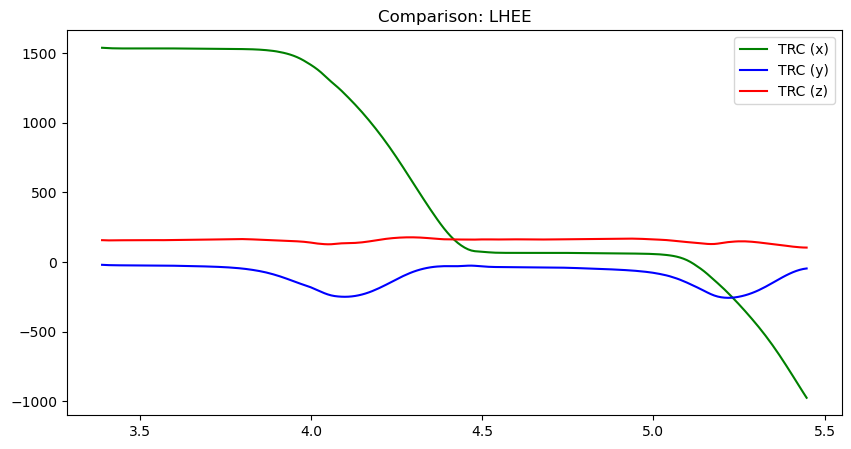

In [27]:
# TRC Data Load
trc_df = pd.read_csv(trc_file, sep='\t', skiprows=6, header=None)
names = pd.read_csv(trc_file, sep='\t', skiprows=3, nrows=0).columns.tolist()

# --- PLOTTING FUNCTION ---
def plot_point_comparison(marker_name, c3d_obj, trc_data, marker_names_list):
    """
    Plots C3D and TRC data. 
    Adjust the index in raw_data to match your coordinate system mapping.
    """
    # Find column
    trcmarker_index = marker_names_list.index(marker_name)
    col_start = trcmarker_index
    
    # Extract TRC
    trc_x = trc_data.iloc[:, col_start]*1000
    trc_y = trc_data.iloc[:, col_start + 1]*1000
    trc_z = trc_data.iloc[:, col_start + 2]*1000
    # Extract the time vector from the TRC file
    time_trc = trc_data.iloc[:, 1]

    # Extract C3D
    c3d_labels = c3d_obj['parameters']['POINT']['LABELS']['value']
    c3dmarker_idx = c3d_labels.index(marker_name)

    # Get the sampling rate (frames per second)
    rate = c3d_obj['parameters']['POINT']['RATE']['value'][0]

    # Generate the time vector based on the number of frames
    num_frames = c3d_obj['data']['points'].shape[2]
    time_c3d = [i / rate for i in range(num_frames)]

    #c3dfilt_labels = c3dfilt_obj['parameters']['POINT']['LABELS']['value']
    #markerfilt_idx = c3dfilt_labels.index(marker_name)
    
    # Use your manual mapping here:
    # Change the index [0, 1, or 2] to match your discovered TRC/C3D axis correspondence
    c3d_x = c3d_obj['data']['points'][0, c3dmarker_idx, :] 
    c3d_y = c3d_obj['data']['points'][1, c3dmarker_idx, :] 
    c3d_z = c3d_obj['data']['points'][2, c3dmarker_idx, :] 

    #c3dfilt_x = c3d_obj['data']['points'][0, markerfilt_idx, :] 
    
    # DB1 TRC z = C3D x; TRC x = C3D y; TRC y = C3D z

    # Plotting
    plt.figure(figsize=(10, 5))
    #plt.plot(time_c3d, c3d_x, label='C3D (x)', color='green', linestyle='--')
    #plt.plot(c3dfilt_x, label='C3D (x)', color='black', linestyle='--')
    plt.plot(time_trc, trc_x, label='TRC (x)', color='green')
    #plt.plot(time_c3d, c3d_y, label='C3D (y)', color='blue', linestyle='--')
    plt.plot(time_trc, trc_y, label='TRC (y)', color='blue')
    #plt.plot(time_c3d, c3d_z, label='C3D (z)', color='red', linestyle='--')
    plt.plot(time_trc, trc_z, label='TRC (z)', color='red')
    plt.title(f"Comparison: {marker_name}")
    plt.legend()
    plt.show()

# Run the comparison
plot_point_comparison("LHEE", c, trc_df, names)

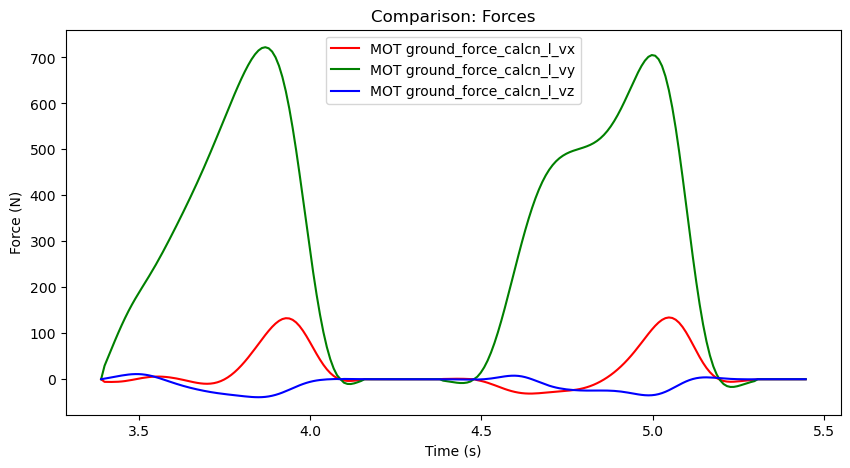

In [29]:

# --- USAGE ---
# Define the lists of channels to compare
#c3d_forces = ["Fx1", "Fy1", "Fz1"]
c3d_forces = ["Force.Fx2", "Force.Fy2", "Force.Fz2"]
#c3d_forces = ["Channel_03", "Channel_08", "Channel_12"]

#c3d_moments = ["Mx1", "My1", "Mz1"]
c3d_moments = ["Moment.Mx1", "Moment.My1", "Moment.Mz1"]

mot_forces = ["ground_force_calcn_l_vx", "ground_force_calcn_l_vy", "ground_force_calcn_l_vz"]
mot_moments = ["ground_force_calcn_l_mx", "ground_force_calcn_l_my", "ground_force_calcn_l_mz"]

def plot_analog_comparison(forces_c3d, forces_mot, moments_c3d, moments_mot, c3d_obj, mot_data):
    # --- Helper to plot a group of 3 components ---
    def plot_group(c3d_names, mot_names, title, ylabel):
        # Time vectors
        time_c3d = [i / c3d_obj['parameters']['ANALOG']['RATE']['value'][0] for i in range(c3d_obj['data']['analogs'].shape[2])]
        time_mot = mot_data.iloc[:, 0]
        
        # Plot C3D components
        plt.figure(figsize=(10, 5))
        colors = ['red', 'green', 'blue']
        #for i, name in enumerate(c3d_names):
        #    idx = c3d_obj['parameters']['ANALOG']['LABELS']['value'].index(name)
        #    plt.plot(time_c3d, c3d_obj['data']['analogs'][0, idx, :], color=colors[i], linestyle='--', label=f'C3D {name}')

        # Plot MOT components (dashed)
        for i, name in enumerate(mot_names):
            plt.plot(time_mot, mot_data[name], color=colors[i], label=f'MOT {name}')
            
        plt.title(title)
        plt.xlabel("Time (s)")
        plt.ylabel(ylabel)
        plt.legend()
        plt.show()

    # Plot Forces
    plot_group(forces_c3d, forces_mot, "Comparison: Forces", "Force (N)")
    
    # Plot Moments
    #plot_group(moments_c3d, moments_mot, "Comparison: Moments", "Moment (Nm)")

plot_analog_comparison(c3d_forces, mot_forces, c3d_moments, mot_moments, c, mot_df)